In [24]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.metrics import f1_score

In [25]:
# Paths
CSV_PATH = "/kaggle/input/labels/labels.csv"
IMAGE_DIR = "/kaggle/input/nih-balanced-and-resized-chest-x-rays/resized_images/resized_images"

In [28]:
# Read and filter data
df = pd.read_csv(CSV_PATH)
df = df[df['Path'].isin(os.listdir(IMAGE_DIR))].reset_index(drop=True)

In [29]:
# Keep only 3 balanced classes
selected_classes = ["No Finding", "Pneumonia", "Effusion"]
df = df[df[selected_classes].sum(axis=1) == 1]  # Only samples with one of the 3 labels
min_count = df[selected_classes].sum().min()
df_balanced = pd.concat([
    df[df[c] == 1].sample(min_count, random_state=42)
    for c in selected_classes
]).reset_index(drop=True)

In [30]:
# Label columns and transforms
label_cols = selected_classes
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [31]:
# Dataset
class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        self.imgs = dataframe['Path'].values
        self.labels = dataframe[label_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path = os.path.join(self.image_dir, self.imgs[idx])
        image = Image.open(path).convert("L")
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        return image, label

In [32]:
# Dataloaders
train_df, test_df = train_test_split(df_balanced, test_size=0.2, random_state=42)
train_ds = ChestXrayDataset(train_df, IMAGE_DIR, train_transform)
test_ds = ChestXrayDataset(test_df, IMAGE_DIR, test_transform)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

In [33]:
# Model
CustomCNN = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=3, padding=0), nn.ReLU(),
    nn.Conv2d(64, 64, kernel_size=3, padding=0), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(64, 128, kernel_size=3, padding=0), nn.BatchNorm2d(128), nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),
    nn.Conv2d(128, 128, kernel_size=3, padding=0), nn.ReLU(),
    nn.AdaptiveMaxPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 3)  # Only 3 classes
)

In [34]:
# Training setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CustomCNN.to(device)
pos_weight = torch.tensor([1.0, 1.0, 1.0], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [21]:
# training loop
from sklearn.metrics import classification_report

EPOCHS = 30
threshold = 0.3

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * images.size(0)

    model.eval()
    total_val_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs).cpu().numpy()
            preds = (probs > threshold).astype(int)

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    y_true = np.vstack(all_labels)
    y_pred = np.vstack(all_preds)

    f1 = f1_score(y_true, y_pred, average="micro", zero_division=0)
    acc = (y_true == y_pred).mean(axis=1).mean()
    scheduler.step(total_val_loss / len(test_loader.dataset))

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {total_train_loss / len(train_loader.dataset):.4f} - "
          f"Val Loss: {total_val_loss / len(test_loader.dataset):.4f} - "
          f"F1 Score: {f1:.4f} - "
          f"Accuracy: {acc:.4f}")

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/30 - Train Loss: 0.6593 - Val Loss: 0.6464 - F1 Score: 0.5000 - Accuracy: 0.3333
Epoch 2/30 - Train Loss: 0.6477 - Val Loss: 0.6351 - F1 Score: 0.5000 - Accuracy: 0.3517
Epoch 3/30 - Train Loss: 0.6429 - Val Loss: 0.6362 - F1 Score: 0.5025 - Accuracy: 0.3478
Epoch 5/30 - Train Loss: 0.6418 - Val Loss: 0.6361 - F1 Score: 0.5005 - Accuracy: 0.3399
Epoch 6/30 - Train Loss: 0.6398 - Val Loss: 0.6358 - F1 Score: 0.5005 - Accuracy: 0.3346
Epoch 7/30 - Train Loss: 0.6394 - Val Loss: 0.6343 - F1 Score: 0.5035 - Accuracy: 0.3530
Epoch 8/30 - Train Loss: 0.6398 - Val Loss: 0.6352 - F1 Score: 0.5025 - Accuracy: 0.3504
Epoch 9/30 - Train Loss: 0.6384 - Val Loss: 0.6347 - F1 Score: 0.5000 - Accuracy: 0.3491
Epoch 10/30 - Train Loss: 0.6390 - Val Loss: 0.6335 - F1 Score: 0.5000 - Accuracy: 0.3701
Epoch 11/30 - Train Loss: 0.6371 - Val Loss: 0.6338 - F1 Score: 0.4968 - Accuracy: 0.3753
Epoch 12/30 - Train Loss: 0.6342 - Val Loss: 0.6330 - F1 Score: 0.4995 - Accuracy: 0.3504
Epoch 13/30 - Trai

In [23]:
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.3).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())

y_true = np.vstack(all_labels)
y_pred = np.vstack(all_preds)

report = classification_report(
    y_true, y_pred,
    target_names=["No Finding", "Pneumonia", "Effusion"],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
No Finding,0.410714,0.758242,0.532819,91.0
Pneumonia,0.309524,1.000000,0.472727,78.0
Effusion,0.344498,0.847059,0.489796,85.0
micro avg,0.348172,0.862205,0.496036,254.0
macro avg,0.354912,0.868434,0.498447,254.0
weighted avg,0.357481,0.862205,0.499968,254.0
samples avg,0.352362,0.862205,0.495407,254.0


In [35]:
torch.save(model.state_dict(), "customcnn_chestxray_3classes.pth")

In [39]:
model = CustomCNN.to(device)
model.load_state_dict(torch.load("/kaggle/input/customcnn_chestxray14_3c/pytorch/default/1/customcnn_chestxray_3classes.pth", map_location=device, weights_only=True))
model.eval()

Sequential(
  (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (3): ReLU()
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
  (10): ReLU()
  (11): AdaptiveMaxPool2d(output_size=(1, 1))
  (12): Flatten(start_dim=1, end_dim=-1)
  (13): Linear(in_features=128, out_features=64, bias=True)
  (14): ReLU()
  (15): Dropout(p=0.5, inplace=False)
  (16): Linear(in_features=64, out_features=32, bias=True)
  (17): ReLU()
  (18): Linear(in_features=32, out_features=3, bias=True)
)

# GRAD-CAM

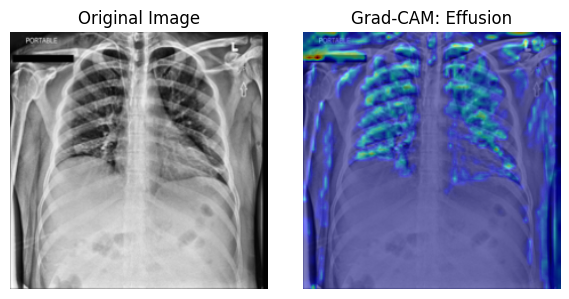

In [41]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2
import gc

torch.cuda.empty_cache()
gc.collect()

target_layer = model[8]
class_names = ["No Finding", "Pneumonia", "Effusion"]

# Hook setup
activations = []
grads = []

def forward_hook(module, input, output):
    activations.append(output)

def backward_hook(module, grad_input, grad_output):
    grads.append(grad_output[0])

handle_f = target_layer.register_forward_hook(forward_hook)
handle_b = target_layer.register_full_backward_hook(backward_hook)

img_tensor, label = test_ds[0]
input_tensor = img_tensor.unsqueeze(0).to(device)  # (1, 1, 256, 256)
output = model(input_tensor)
pred_class = output[0].sigmoid().detach().cpu().numpy()

class_idx = np.argmax(pred_class)

model.zero_grad()
output[0, class_idx].backward()

act = activations[0].squeeze(0)  # shape: (128, H, W)
grad = grads[0].squeeze(0)

weights = grad.mean(dim=(1, 2)) 
cam = (weights[:, None, None] * act).sum(0).cpu().detach().numpy()
cam = np.maximum(cam, 0)
cam = cv2.resize(cam, (256, 256))
cam -= cam.min()
cam /= cam.max()

img_np = img_tensor.squeeze(0).cpu().numpy()
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img_np, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_np, cmap='gray')
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM: {class_names[class_idx]}")
plt.axis("off")
plt.tight_layout()
plt.show()

handle_f.remove()
handle_b.remove()

# SHAP

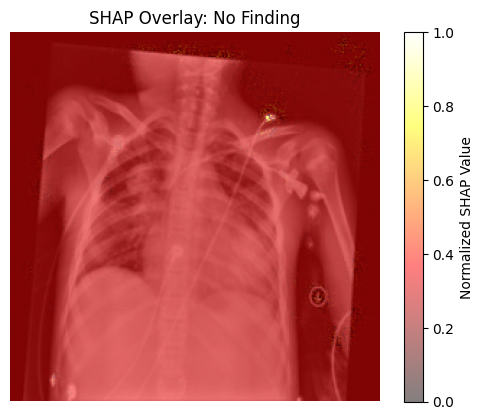

In [51]:
shap_map = shap_values[0][0] 
shap_map = shap_map.squeeze() 

shap_norm = (shap_map - shap_map.min()) / (shap_map.max() - shap_map.min())

plt.imshow(input_np[0, :, :, 0], cmap='gray')  # original image
plt.imshow(shap_norm, cmap='hot', alpha=0.5)   # heatmap overlay
plt.title(f"SHAP Overlay: {selected_classes[0]}")
plt.axis('off')
plt.colorbar(label="Normalized SHAP Value")
plt.show()

# LIME

  0%|          | 0/1000 [00:00<?, ?it/s]

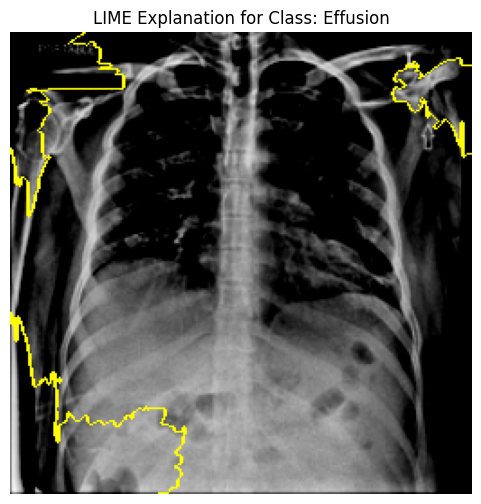

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from skimage.color import rgb2gray, gray2rgb

original_img = img_tensor.squeeze().cpu().numpy()  # shape (256, 256)
rgb_image = gray2rgb(original_img)  # shape (256, 256, 3), needed by LIME

def predict_fn(x):
    x_gray = np.dot(x[..., :3], [0.2989, 0.5870, 0.1140])
    x_tensor = torch.tensor(x_gray).unsqueeze(1).float().to(device)  # (B, 1, 256, 256)
    with torch.no_grad():
        outputs = model(x_tensor)
        probs = torch.sigmoid(outputs).cpu().numpy()
    return probs

explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(
    rgb_image,
    classifier_fn=predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

from skimage.segmentation import mark_boundaries
temp, mask = explanation.get_image_and_mask(
    label=explanation.top_labels[0],
    positive_only=True,
    hide_rest=False,
    num_features=5,
    min_weight=0.0
)

plt.figure(figsize=(6, 6))
plt.imshow(mark_boundaries(rgb_image, mask))
plt.title(f"LIME Explanation for Class: {selected_classes[explanation.top_labels[0]]}")
plt.axis('off')
plt.show()

# DeepDream

Iteration 0, Loss: 214.2496
Iteration 10, Loss: 214.3458
Iteration 20, Loss: 214.4420


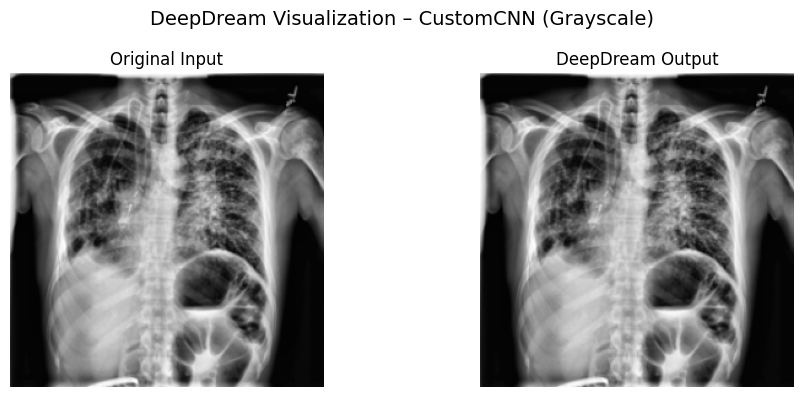

In [55]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import random

dream_model = nn.Sequential(
    model[0],  # Conv2d(1, 64, kernel_size=3)
    model[1],  # ReLU
    model[2],  # Conv2d(64, 64, kernel_size=3)
    model[3],  # ReLU
).to(device).eval()

def deprocess_grayscale(tensor):
    img = tensor.squeeze().detach().cpu().numpy()
    img = (img * 0.5) + 0.5 
    return np.clip(img, 0, 1)

def deepdream(image, model, iterations=30, lr=0.01):
    image = image.clone().detach().to(device).requires_grad_(True)
    for i in range(iterations):
        model.zero_grad()
        out = model(image)
        loss = out.norm()
        loss.backward()
        image.data += lr * image.grad.data
        image.grad.data.zero_()
        if i % 10 == 0:
            print(f"Iteration {i}, Loss: {loss.item():.4f}")
    return image.detach()

i = random.randint(0, len(test_ds) - 1)
img_tensor, label = test_ds[i]
input_tensor = img_tensor.unsqueeze(0).to(device)  # (1, 1, 256, 256)

dreamed_tensor = deepdream(input_tensor, dream_model)

original_img = deprocess_grayscale(input_tensor)
dreamed_img = deprocess_grayscale(dreamed_tensor)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(original_img, cmap='gray')
plt.title("Original Input")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(dreamed_img, cmap='gray')
plt.title("DeepDream Output")
plt.axis("off")

plt.suptitle("DeepDream Visualization – CustomCNN (Grayscale)", fontsize=14)
plt.tight_layout()
plt.show()